Script to identify any skew in horizontal and vertical eye movements as a function of different conditions

In [2]:
import numpy as np
import pandas as pd
import copy

df_1d = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/20250516_timecourse_df_allsubs_lowerexclusion.csv')

# change name of 'mean_gaze_x' to  'mean_x'
df_1d = df_1d.rename(columns={'mean_gaze_x': 'mean_x'})
# change name of 'mean_gaze_y' to 'mean_y'
df_1d = df_1d.rename(columns={'mean_gaze_y': 'mean_y'})

print(df_1d.head())

# keep only conditions 2 and 3
df_1d = df_1d[df_1d['condition'].isin([2,3])]
# keep only columns: sub, condition, mean_x, mean_y, time_rounded_relative
df_1d = df_1d[['sub', 'condition', 'mean_x', 'mean_y', 'time_rounded_relative']]
# rename time_rounded_relative to time
df_1d = df_1d.rename(columns={'time_rounded_relative': 'time'})
# round time_rounded_relative to 3 decimal places
df_1d['time'] = df_1d['time'].apply(lambda x: round(x, 3))
# order by: subject, time, condition
df_1d = df_1d.sort_values(by=['sub', 'time', 'condition'])
# reset index
df_1d = df_1d.reset_index(drop=True)
# smooth mean_x and mean_y within each subject and condition using a gaussian kernel
def smooth_mean(df, sigma, window_size=50):
    df['mean_x'] = df.groupby(['sub', 'condition'])['mean_x'].transform(lambda x: x.rolling(window=window_size, win_type='gaussian', min_periods=1, center=True).mean(std=sigma))
    df['mean_y'] = df.groupby(['sub', 'condition'])['mean_y'].transform(lambda x: x.rolling(window=window_size, win_type='gaussian', min_periods=1, center=True).mean(std=sigma))
    return df
df_1d = smooth_mean(df_1d, sigma=4.25, window_size=20) # roughly corresponds to a window size of 10ms as due to sigma=4.25, the kernel is 10ms wide
# how much further right do we go for 2 than 3? 
# need to check if 2-3 > 0
# if so, 2 is further right
# if not, 3 is further right
df_2 = copy.deepcopy(df_1d[df_1d['condition'] == 2])
# drop index
df_2 = df_2.reset_index(drop=True)
df_3 = df_1d[df_1d['condition'] == 3]
# drop index
df_3 = df_3.reset_index(drop=True)

df_2_plot = df_2.copy()
df_3_plot = df_3.copy()

change_x = df_2['mean_x'] - df_3['mean_x']
change_y = df_2['mean_y'] - df_3['mean_y']
change_x = change_x.reset_index(drop=True)
change_y = change_y.reset_index(drop=True)
df_2['change_x'] = change_x
df_2['change_y'] = change_y
df_2 = df_2.drop(['mean_x', 'mean_y', 'condition'], axis=1)
df_change = df_2.copy()
# remove sub-09 because their data is almost all nan
df_change = df_change[df_change['sub'] != 'sub-09']
# remove any nans
df_change = df_change.dropna()


# order by subject and time
df_change = df_change.sort_values(by=['sub', 'time'])
df_change.head()

      sub  condition    mean_x    mean_y  time_rounded_relative  method  \
0  sub-01          1 -0.004722 -0.018148                 -0.501  median   
1  sub-01          1 -0.004618 -0.018588                 -0.500  median   
2  sub-01          1 -0.005880 -0.018194                 -0.499  median   
3  sub-01          1 -0.003403 -0.017500                 -0.498  median   
4  sub-01          1 -0.003519 -0.018449                 -0.497  median   

          time  time_rounded  timecourse_val  n_nans  
0  1243.121694     1243.1220             NaN     0.0  
1  1258.560966     1258.5610             NaN     0.0  
2  1297.144311     1297.1445             NaN     0.0  
3  1258.563151     1258.5630             NaN     0.0  
4  1043.118975     1043.1190             NaN     0.0  


,sub,time,change_x,change_y
0,sub-01,-0.501,-0.000248,-0.002711
1,sub-01,-0.500,-0.000246,-0.002720
2,sub-01,-0.499,-0.000228,-0.002718
3,sub-01,-0.498,-0.000224,-0.002702
4,sub-01,-0.497,-0.000208,-0.002671


In [3]:
df_2[df_2['sub'] == 'sub-08']

,sub,time,change_x,change_y


In [4]:
# number of subjects?
subs = df_change['sub'].unique()
n_subs = len(subs)
n_subs

46

In [5]:
subs

array(['sub-01', 'sub-03', 'sub-06', 'sub-07', 'sub-10', 'sub-11',
       'sub-12', 'sub-13', 'sub-14', 'sub-15', 'sub-16', 'sub-17',
       'sub-19', 'sub-21', 'sub-22', 'sub-23', 'sub-24', 'sub-25',
       'sub-26', 'sub-27', 'sub-28', 'sub-29', 'sub-30', 'sub-31',
       'sub-34', 'sub-36', 'sub-37', 'sub-38', 'sub-39', 'sub-42',
       'sub-43', 'sub-45', 'sub-46', 'sub-47', 'sub-48', 'sub-49',
       'sub-51', 'sub-52', 'sub-53', 'sub-55', 'sub-56', 'sub-58',
       'sub-59', 'sub-60', 'sub-61', 'sub-62'], dtype=object)

In [6]:
from mne.stats import spatio_temporal_cluster_1samp_test, ttest_ind_no_p

# data should be subject x space x time

# get data for corr_2d
data_change = df_change.pivot(index='sub', columns='time', values='change_x')
# turn into np array of shape sub x time x 1
data_change = data_change.values.reshape(data_change.shape[0], 1, data_change.shape[1])
# run cluster test
degf = data_change.shape[0] - 1
from scipy import stats
T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
                                                                     n_permutations=10000, 
                                                                     tail=0,
                                                                     threshold=None
                                                                     )
print(cluster_p_values_change)
# get timepoints for significant clusters
# get indices of clusters where p<0.05
sig_clusters_change = [i for i, p in enumerate(cluster_p_values_change) if p < 0.05]
print(sig_clusters_change)
# get timepoints for each sig cluster
timepoints_change = []
for cluster_change in sig_clusters_change:
    timepoints_change.append(clusters_change[cluster_change][1])
timepoints_change = [item for sublist in timepoints_change for item in sublist]

sig_timepoints = [(i/1000)-0.5 for i in timepoints_change]
print(sig_timepoints[0:10])
print(sig_timepoints[-10:])

Using a threshold of 2.014103
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 14 clusters


/var/folders/yf/gwy8by0x6l56gb82wlwny7ym0000gn/T/ipykernel_845/380873137.py:12: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Permuting : 9999/9999 [00:12<00:00,  789.92it/s]


[8.295e-01 8.724e-01 1.000e-04 8.133e-01 7.059e-01 2.788e-01 7.915e-01
 8.568e-01 3.902e-01 7.938e-01 8.744e-01 6.905e-01 8.904e-01 3.524e-01]
[2]
[0.9219999999999999, 0.923, 0.9239999999999999, 0.925, 0.9259999999999999, 0.927, 0.9279999999999999, 0.929, 0.9299999999999999, 0.931]
[1.73, 1.7309999999999999, 1.7320000000000002, 1.733, 1.734, 1.7349999999999999, 1.7360000000000002, 1.737, 1.738, 1.7389999999999999]


In [7]:
import numpy as np

# Set a significance threshold for p-values
significance_threshold = 0.05
# Identify the significant clusters based on p-values
significant_clusters_indices = np.where(cluster_p_values_change < significance_threshold)[0]
# Extract the t-values corresponding to those significant clusters
significant_t_values = []
# Loop through each significant cluster index and extract the corresponding t-value
for cluster_index in significant_clusters_indices:
    # Get the indices of the current cluster
    cluster_indices = clusters_change[cluster_index]
    # Extract the t-values for these indices from T_obs_change
    cluster_t_values = T_obs_change[cluster_indices]
    # Append the maximum t-value for each significant cluster (or you could average, depending on your approach)
    significant_t_values.append(np.max(cluster_t_values))  # or np.mean(cluster_t_values)
    
# Print the significant t-values
print("Significant t-values for clusters:")
print(significant_t_values)


Significant t-values for clusters:
[5.485486945030115]


In [8]:

for cluster_change in sig_clusters_change:
    print(clusters_change[cluster_change][0][0], clusters_change[cluster_change][0][-1])
    # print tval
    # print pval
    print(cluster_p_values_change[cluster_change])


0 0
0.0001


In [9]:
df_change['change_x'] = df_change['change_x'].apply(lambda x: x*960)


/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


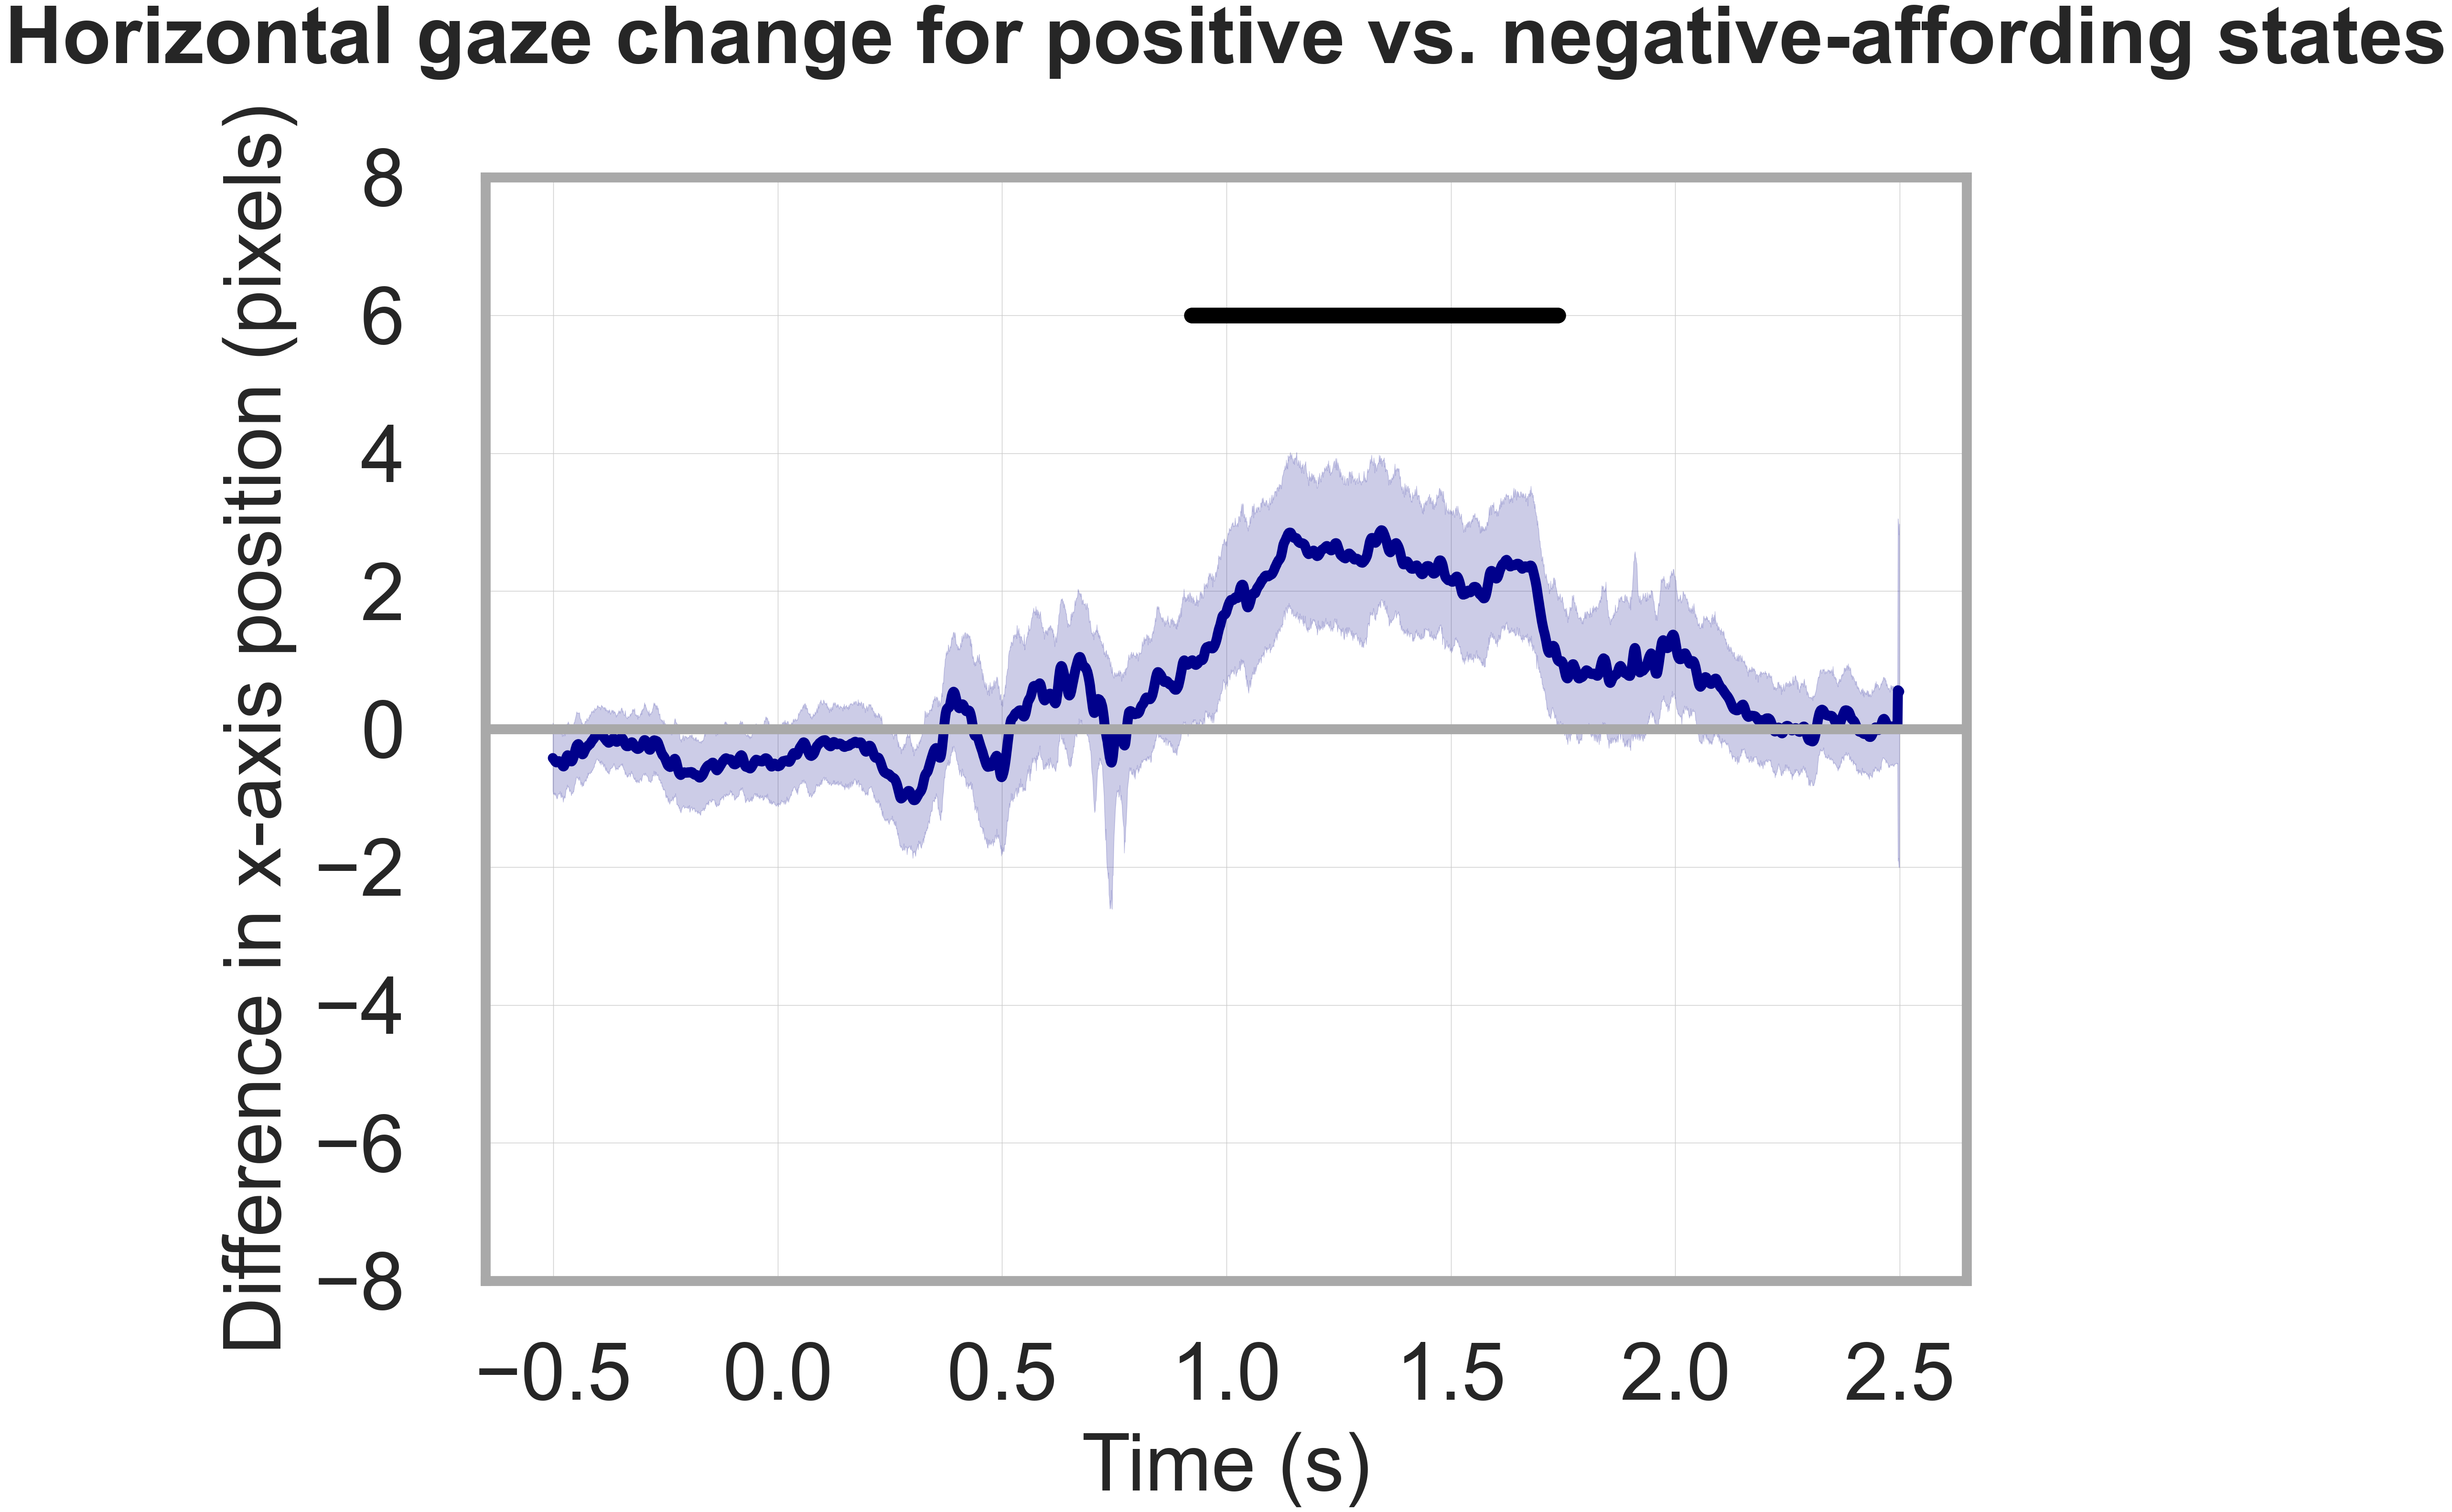

In [10]:

from matplotlib import pyplot as plt
import seaborn as sns

# multiply change_x by 1080
#df_change['change_x'] = df_change['change_x'].apply(lambda x: x*960)
# take only every 10th row
#df_change = df_change.iloc[::10, :]
# set sns style as wgrid
sns.set(style='whitegrid')
# set plot size as 10*20
plt.figure(figsize=(40, 30))
# lineplot of cor_2d over time
ax = sns.lineplot(x='time', y='change_x', data=df_change, color='darkblue', linewidth=15)
# add a dark line at y=0
plt.axhline(0, color='darkgrey', linewidth=15)
# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)
# change x axis label to 'Trial group'
plt.xlabel('Time (s)', fontsize=120, labelpad=25)
# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)
# make y axis labels bigger
plt.yticks(fontsize=120)
# change y axis label to 'Performance'
plt.ylabel('Difference in x-axis position (pixels)', fontsize=120, labelpad=25)
# add title
plt.title('Horizontal gaze change for positive vs. negative-affording states', fontsize=120, y=1.1, fontweight='bold')
# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')
# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579
for timepoint in sig_timepoints:
    # plot a dot at y=1.1
    plt.scatter(timepoint, 6, color='black', s=500)
# set ylim as -10 to 13
plt.ylim(-8, 8)
plt.show()

/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: Futur

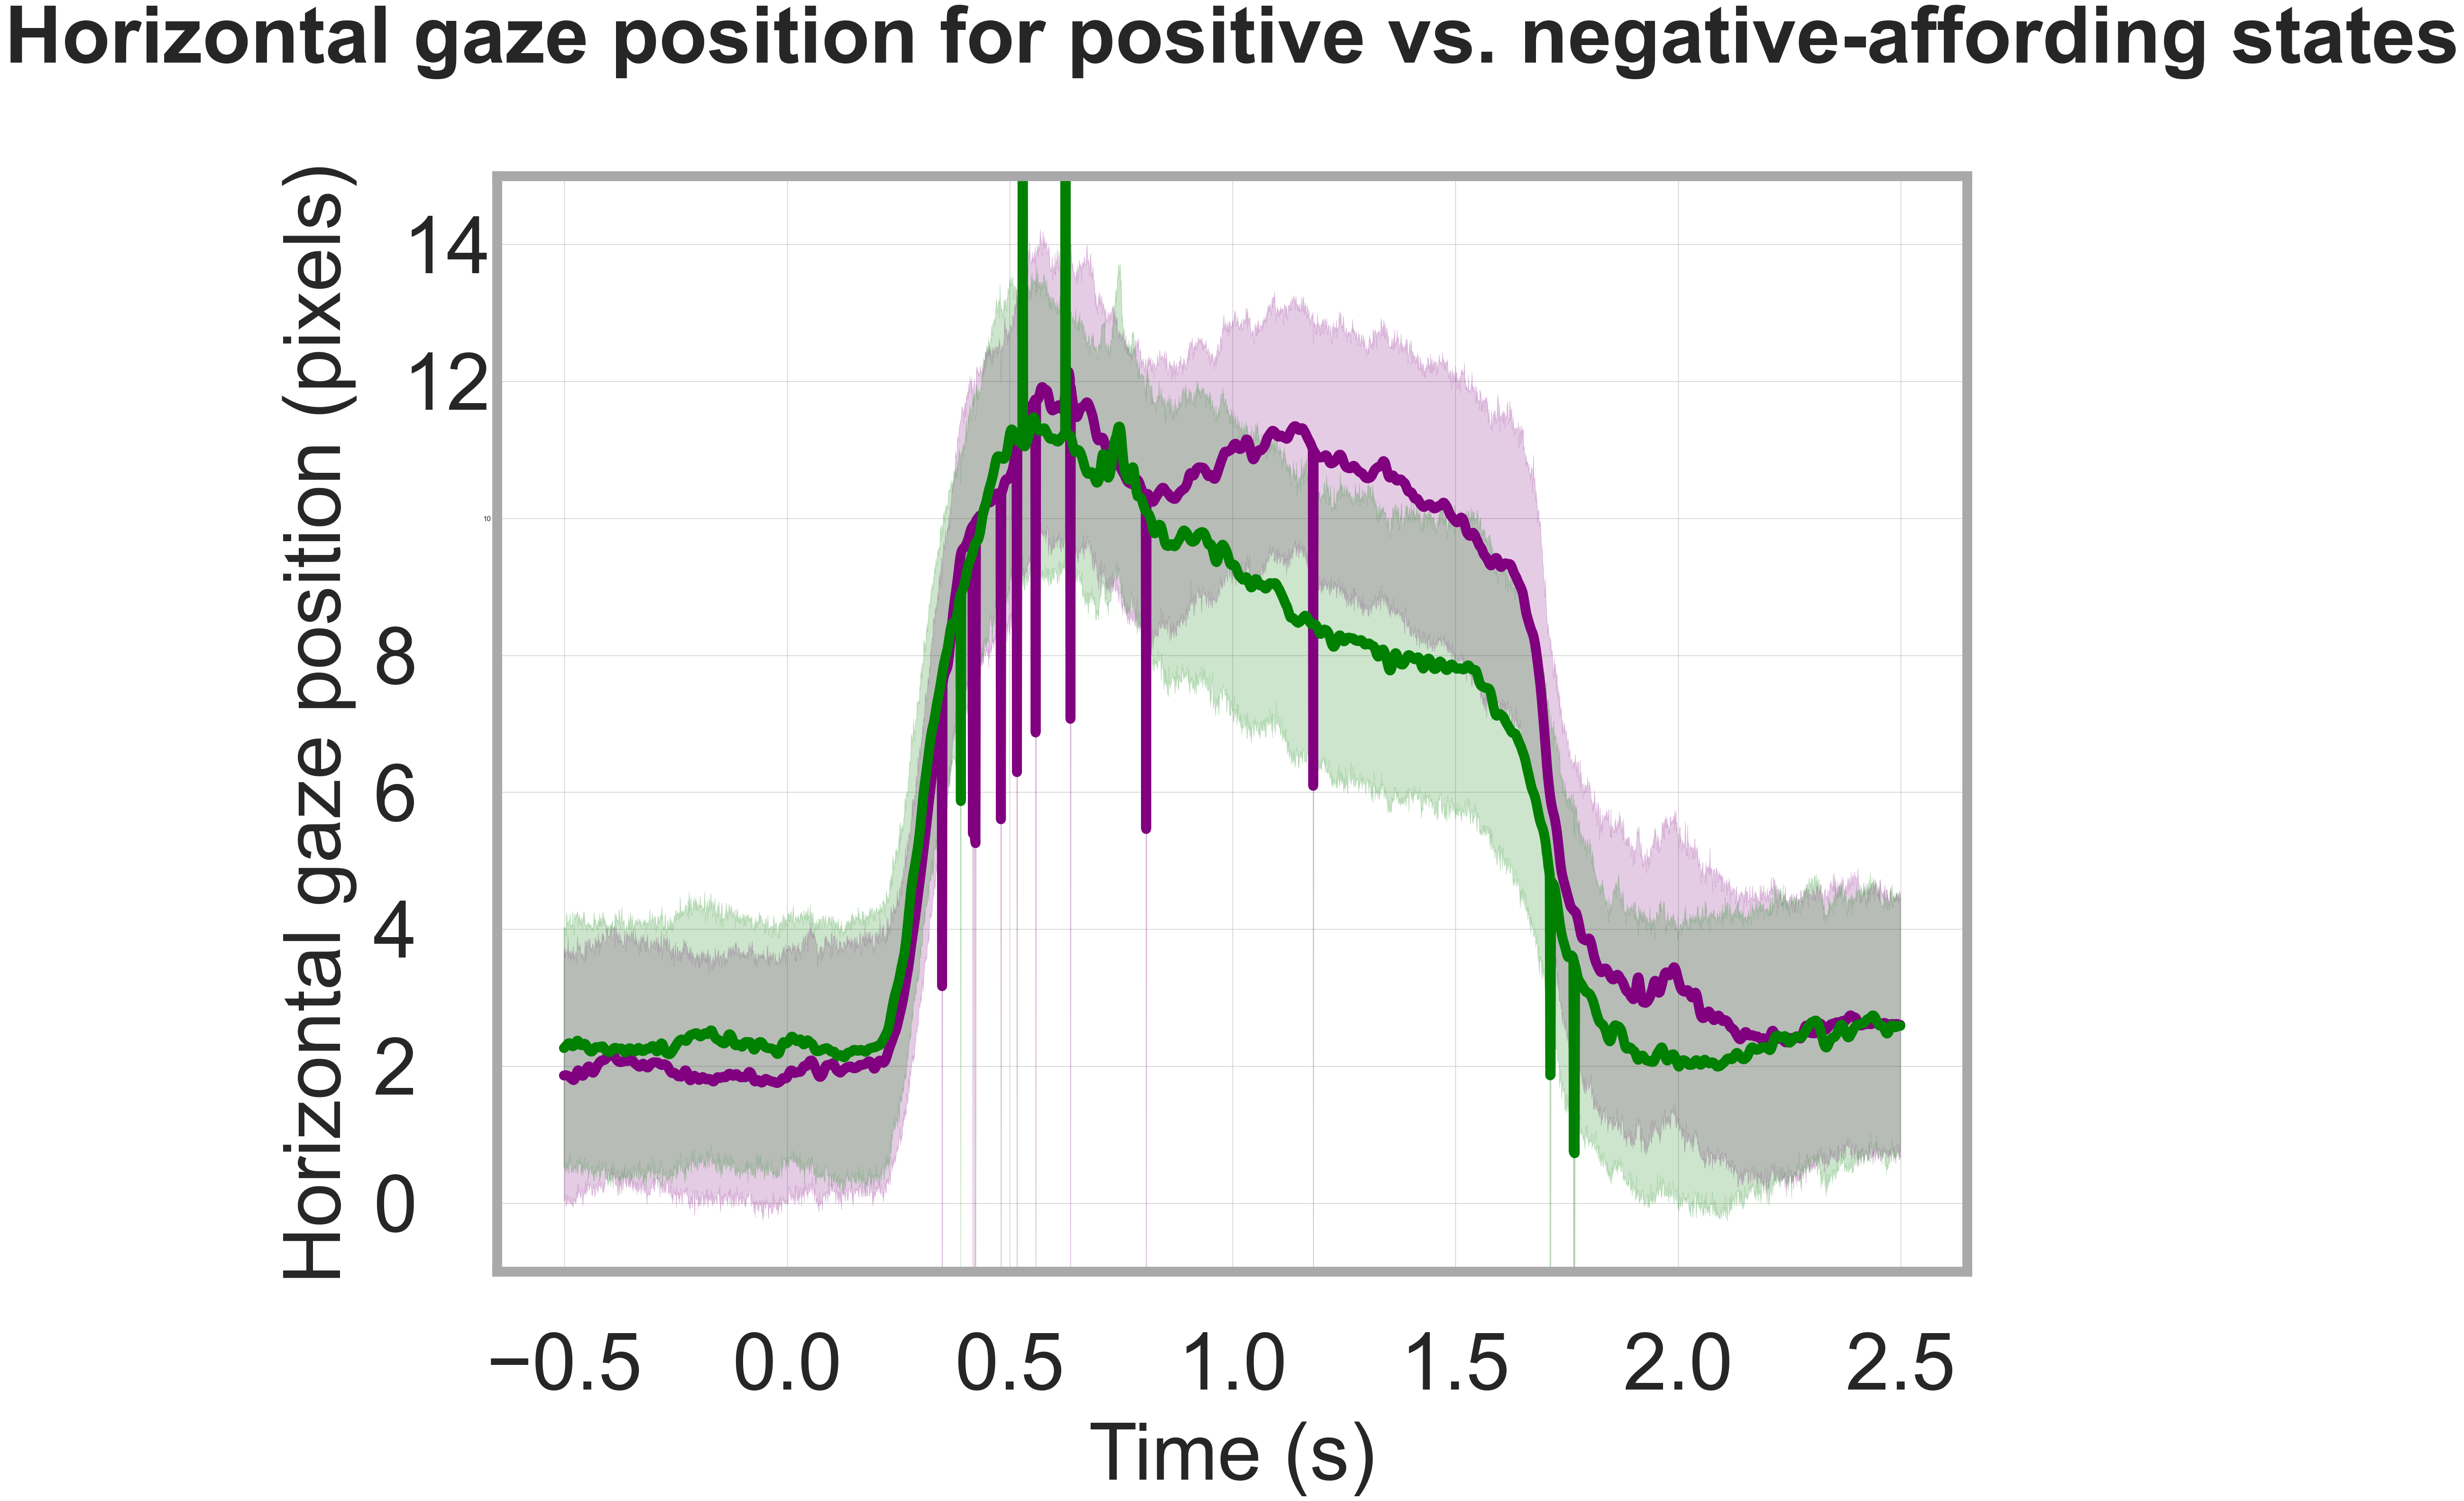

In [11]:

from matplotlib import pyplot as plt
import seaborn as sns


df_2_plot['mean_x'] = df_2_plot['mean_x'].apply(lambda x: x*960)
df_3_plot['mean_x'] = df_3_plot['mean_x'].apply(lambda x: x*960)


# multiply change_x by 1080
#df_change['change_x'] = df_change['change_x'].apply(lambda x: x*960)
# take only every 10th row
#df_change = df_change.iloc[::10, :]
# set sns style as wgrid
sns.set(style='whitegrid')
# set plot size as 10*20
plt.figure(figsize=(40, 30))
# lineplot of cor_2d over time
ax = sns.lineplot(x='time', y='mean_x', data=df_2_plot, color='purple', linewidth=15)
ax = sns.lineplot(x='time', y='mean_x', data=df_3_plot, color='green', linewidth=15)

# add a dark line at y=0
#plt.axhline(0, color='darkgrey', linewidth=15)
# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)
# change x axis label to 'Trial group'
plt.xlabel('Time (s)', fontsize=120, labelpad=25)
# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)
# make y axis labels bigger
plt.yticks(fontsize=120)
# change y axis label to 'Performance'
plt.ylabel('Horizontal gaze position (pixels)', fontsize=120, labelpad=25)
# add title
plt.title('Horizontal gaze position for positive vs. negative-affording states', fontsize=120, y=1.1, fontweight='bold')
# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')
# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579
#for timepoint in sig_timepoints:
    # plot a dot at y=1.1
#    plt.scatter(timepoint, 14.5, color='black', s=500)
# set ylim as -10 to 13
plt.ylim(-1, 15)
plt.show()

In [12]:
change_x_list = df_change['change_x'].to_list()
min(change_x_list)

-40.751745757873984

In [13]:
# same for change y
# data should be subject x space x time
# get data for corr_2d
data_change = df_change.pivot(index='sub', columns='time', values='change_y')
# turn into np array of shape sub x time x 1
data_change = data_change.values.reshape(data_change.shape[0], data_change.shape[1], 1)
# run cluster test
degf = data_change.shape[0] - 1
from scipy import stats
T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
                                                                     n_permutations=10000, 
                                                                     tail=0,
                                                                     threshold=None
                                                                     )


print(cluster_p_values_change)
sig_clusters_change = [i for i, p in enumerate(cluster_p_values_change) if p < 0.05]
# get timepoints for each sig cluster
timepoints_change_y = []
for cluster_change in sig_clusters_change:
    timepoints_change_y.append(clusters_change[cluster_change][0])
timepoints_change_y = [item for sublist in timepoints_change_y for item in sublist]

sig_timepoints = [(i/1000)-0.5 for i in timepoints_change_y]



Using a threshold of 2.014103
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 9 clusters


/var/folders/yf/gwy8by0x6l56gb82wlwny7ym0000gn/T/ipykernel_845/3664700480.py:10: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_change, clusters_change, cluster_p_values_change, H0_change = spatio_temporal_cluster_1samp_test(data_change,
100%|██████████| Permuting : 9999/9999 [00:12<00:00,  817.55it/s]

[0.0113 0.6912 0.4475 0.7879 0.0763 0.2954 0.8263 0.6227 0.5822]


In [14]:
import numpy as np

# Set a significance threshold for p-values
significance_threshold = 0.05

# Identify the significant clusters based on p-values
significant_clusters_indices = np.where(cluster_p_values_change < significance_threshold)[0]

# Extract the t-values corresponding to those significant clusters
significant_t_values = []

# Loop through each significant cluster index and extract the corresponding t-value
for cluster_index in significant_clusters_indices:
    # Get the indices of the current cluster
    cluster_indices = clusters_change[cluster_index]
    
    # Extract the t-values for these indices from T_obs_change
    cluster_t_values = T_obs_change[cluster_indices]
    
    # Append the maximum t-value for each significant cluster (or you could average, depending on your approach)
    significant_t_values.append(np.max(cluster_t_values))  # or np.mean(cluster_t_values)
    
# Print the significant t-values
print("Significant t-values for clusters:")
print(significant_t_values)


Significant t-values for clusters:
[4.058348074869837]


In [15]:
# print start and end timepoints for each sig cluster

for cluster_change in sig_clusters_change:
    print(clusters_change[cluster_change][0][0], clusters_change[cluster_change][0][-1])
    # print pval

    print(cluster_p_values_change[cluster_change])


# multiply change_x by 1080
df_change['change_y'] = df_change['change_y'].apply(lambda x: x*960)


1691 2122
0.0113


/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


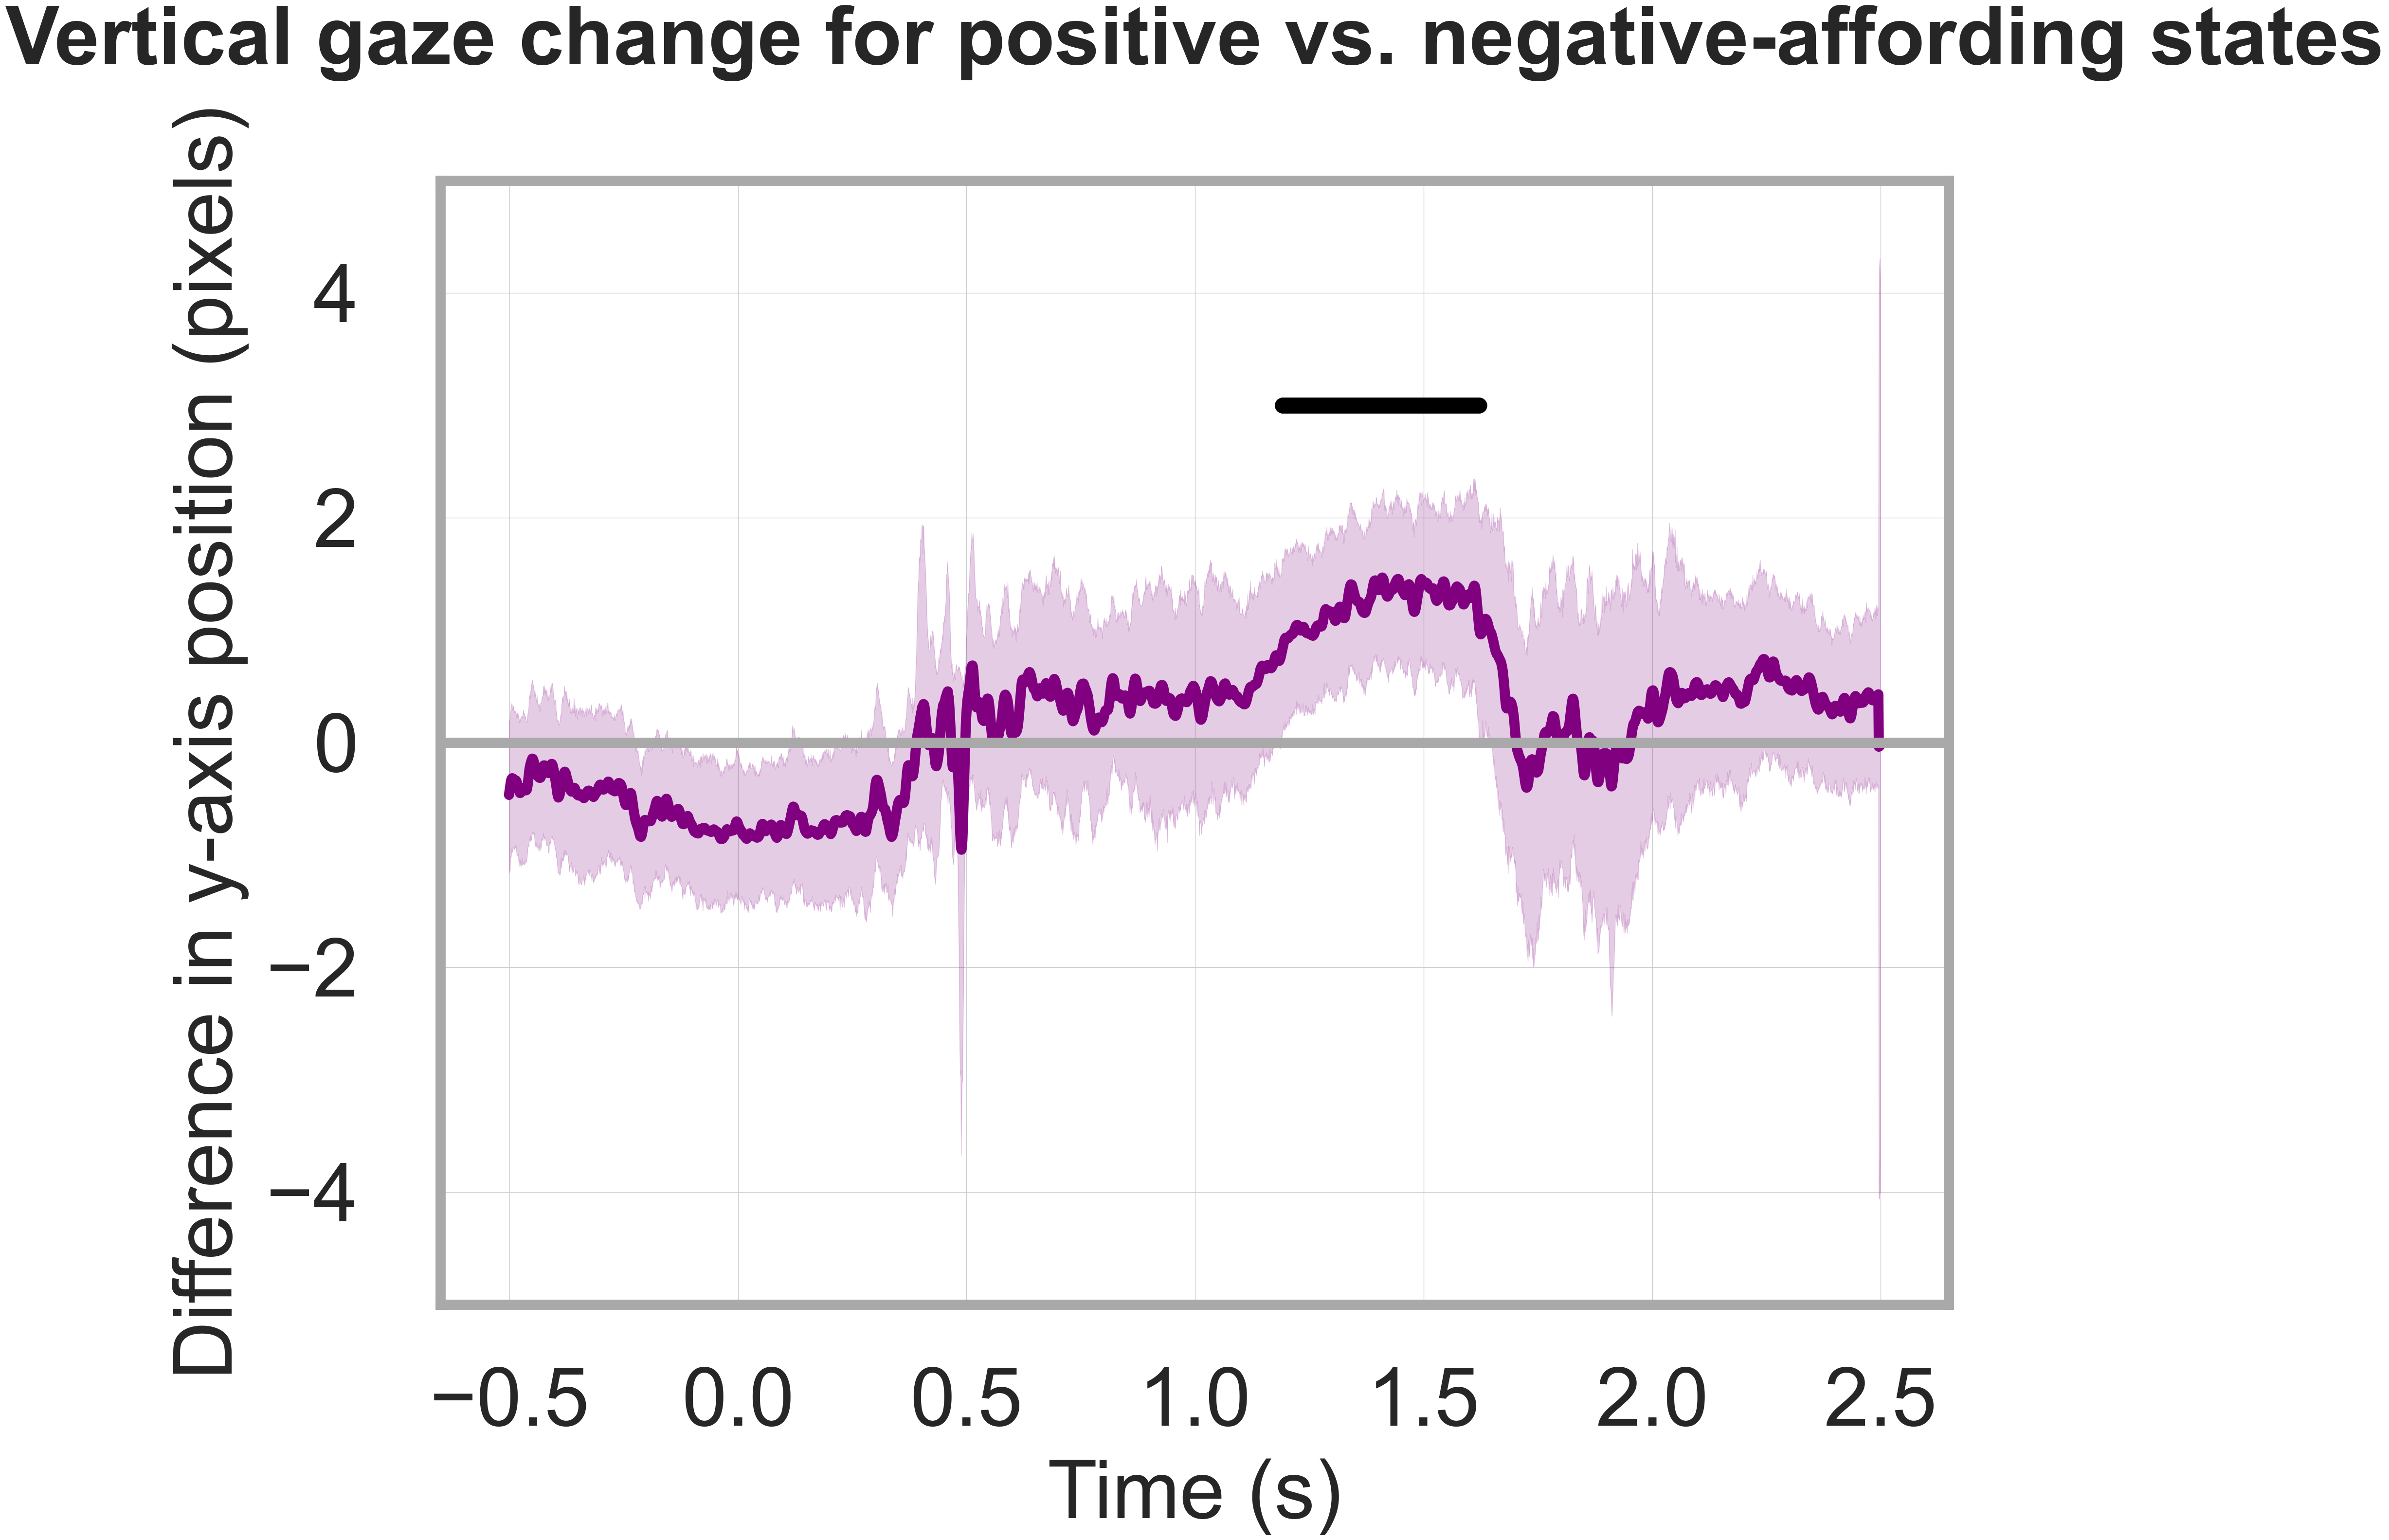

In [16]:

from matplotlib import pyplot as plt
import seaborn as sns

# take only every 10th row
#df_change = df_change.iloc[::10, :]
#df_change['change_y'] = df_change['change_y'].apply(lambda x: x*960)


# set sns style as wgrid
sns.set(style='whitegrid')
# set plot size as 10*20
plt.figure(figsize=(40, 30))
# lineplot of cor_2d over time
ax = sns.lineplot(x='time', y='change_y', data=df_change, color='purple', linewidth=15)
# add a dark line at y=0
plt.axhline(0, color='darkgrey', linewidth=15)
# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)
# change x axis label to 'Trial group'
plt.xlabel('Time (s)', fontsize=120, labelpad=25)
# make x axis labels bigger
plt.xticks(fontsize=120, y=-0.05)
# make y axis labels bigger
plt.yticks(fontsize=120)
# change y axis label to 'Performance'
plt.ylabel('Difference in y-axis position (pixels)', fontsize=120, labelpad=25)
# add title
plt.title('Vertical gaze change for positive vs. negative-affording states', fontsize=120, y=1.1, fontweight='bold')
# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')
# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579
for timepoint in timepoints_change_y:
    # plot a dot at y=1.1
    plt.scatter((timepoint/1000)-0.5, 3, color='black', s=500)
# set ylim as -10 to 13
plt.ylim(-5, 5)
plt.show()

# Find center of cluster for x axis change and take median corr value per subject in that time window 

In [17]:

df_sig = df_change[df_change['time'].isin(sig_timepoints)]
# sort by subject (not numerical)
df_sig = df_sig.sort_values(by='sub')
df_sig.head()


,sub,time,change_x,change_y
1692,sub-01,1.191,5.248590,3.556860
1945,sub-01,1.444,4.675701,3.245191
1944,sub-01,1.443,4.651446,3.212122
1943,sub-01,1.442,4.628302,3.204437
1942,sub-01,1.441,4.597007,3.196935


In [18]:
# take the median of corr_2d per subject
# group by subject and take median of corr_2d
df_sig_med = df_sig.groupby('sub').median()
# flatten the multiindex
df_sig_med = df_sig_med.reset_index()
# save
#df_sig_med.to_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/change_x_median.csv')
# load in df from rdm_correlations.csv
df_rdm = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/rdm_correlations_partial.csv')
# take only rows where sub is in df_sig_med['sub'], which is a column not an index
df_rdm = df_rdm[df_rdm['sub'].isin(df_sig_med['sub'])]
# take only rows where region is ERC
df_rdm = df_rdm[df_rdm['region'] == 'Entorhinal-right']
# take only rows where model is 'affordance'
df_rdm = df_rdm[df_rdm['model'] == 'affordance']
# merge df_sig_med and df_rdm on sub
df_sig_med = df_sig_med.merge(df_rdm, on='sub')
# load in performance info from subject_performances_et.json
import json
with open('/Users/alex/Documents/action_hippo/action_hippo/eyes/subject_performances_et.json') as f:
    data_et_perf = json.load(f)
print(data_et_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_perf'] = [data_et_perf[sub] for sub in df_sig_med['sub']]
# same for subject_performances_all_trials.json
with open('/Users/alex/Documents/action_hippo/action_hippo/eyes/subject_performances_all_trials_et.json') as f:
    data_all_perf = json.load(f)
print(data_all_perf)
# add to df for subjects in data_et_perf
df_sig_med['et_all_perf'] = [data_all_perf[sub] for sub in df_sig_med['sub']]
df_sig_med.head()


{'sub-31': 0.8518518518518519, 'sub-46': 0.8148148148148148, 'sub-09': 0.8421052631578947, 'sub-03': 0.4745762711864407, 'sub-22': 0.7741935483870968, 'sub-55': 0.7301587301587301, 'sub-28': 0.8888888888888888, 'sub-10': 0.9047619047619048, 'sub-17': 0.6666666666666666, 'sub-60': 0.9032258064516129, 'sub-52': 0.8095238095238095, 'sub-25': 0.7868852459016393, 'sub-58': 0.603448275862069, 'sub-04': 0.7708333333333334, 'sub-41': 0.7884615384615384, 'sub-36': 0.54, 'sub-45': 0.9354838709677419, 'sub-32': 0.7142857142857143, 'sub-38': 0.6491228070175439, 'sub-56': 0.5901639344262295, 'sub-21': 0.8, 'sub-19': 0.7457627118644068, 'sub-13': 0.7966101694915254, 'sub-14': 0.6862745098039216, 'sub-26': 0.4827586206896552, 'sub-51': 0.7619047619047619, 'sub-07': 0.984375, 'sub-35': 0.6, 'sub-42': 0.7413793103448276, 'sub-48': 0.6363636363636364, 'sub-05': 0.7719298245614035, 'sub-37': 0.875, 'sub-40': 0.9322033898305084, 'sub-61': 0.7457627118644068, 'sub-16': 0.7090909090909091, 'sub-59': 0.91935

,sub,time,change_x,change_y,model,region,correlation,performance,mean_rdm_value,32_rdm_value,et_perf,et_all_perf
0,sub-01,1.376,5.114118,3.419946,affordance,Entorhinal-right,0.384953,0.976562,15.092949,36.606171,0.849057,0.703125
1,sub-03,1.376,0.538631,-0.564036,affordance,Entorhinal-right,-0.669058,0.814433,-21.217882,-54.525057,0.474576,0.437500
2,sub-06,1.376,4.177150,-0.234592,affordance,Entorhinal-right,0.669058,0.935484,-11.479033,38.871247,0.936508,0.921875
3,sub-07,1.376,11.255536,4.009184,affordance,Entorhinal-right,0.308880,1.000000,42.459915,67.448838,0.984375,0.984375
4,sub-10,1.376,4.999315,-0.358151,affordance,Entorhinal-right,0.354660,0.971963,-23.354801,14.764017,0.904762,0.890625


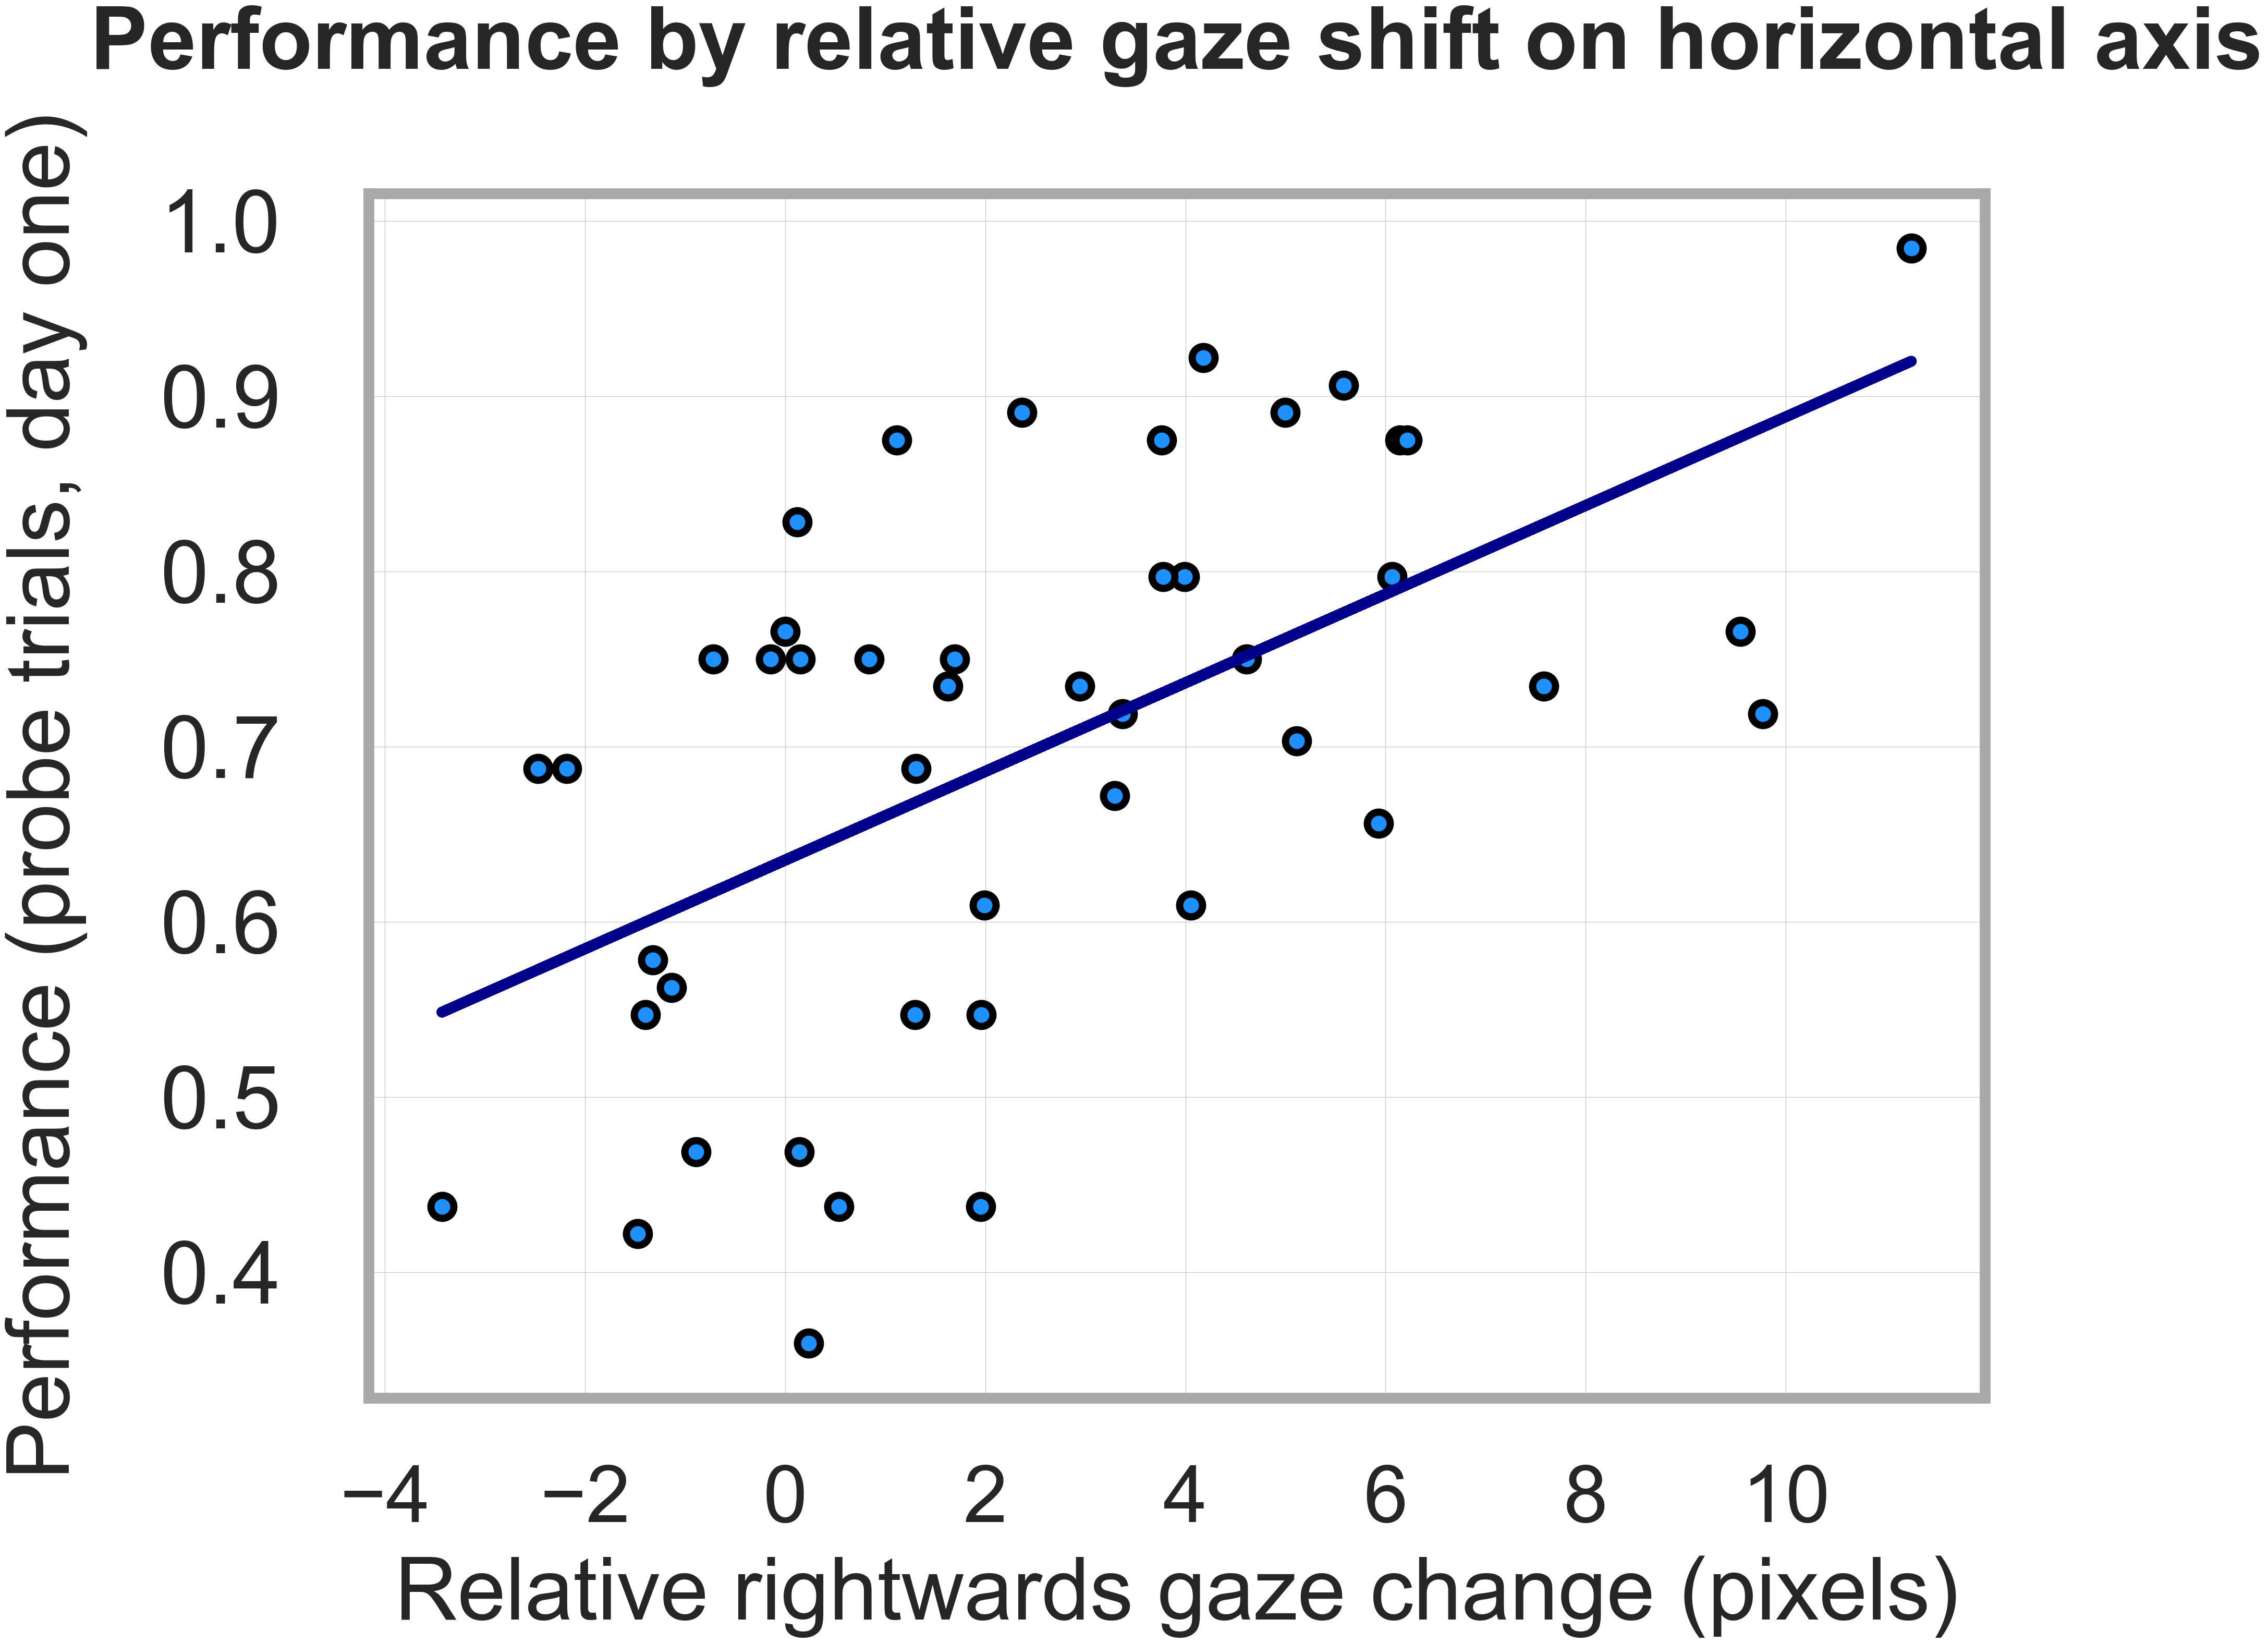

In [21]:
# plot correlation between change_x and correlation

# add regression line
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
# make this plot nicer
# set sns style as wgrid
sns.set(style='whitegrid')
# set plot size as 10*20
plt.figure(figsize=(40, 30))
# multiply change_x by 1080 to get pixels if not already done
#df_sig_med['change_x'] = df_sig_med['change_x'].apply(lambda x: x*1080)
# add y label and x label
plt.ylabel('Performance during eyetracking, day 1', fontsize=30)
plt.xlabel('Change in y position (pixels)', fontsize=30)
# add a title, size 30 and not right next to plot, Change in x position vs performance during eyetracking
plt.title('Change in x position vs performance during eyetracking', pad=20, fontsize=30)
# scatterplot of change_x over time
ax = sns.scatterplot(x='change_x', y='et_all_perf', data=df_sig_med, color='darkblue', s=1000)
x = df_sig_med['change_x']
y = df_sig_med['et_all_perf']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
line = slope*x+intercept
plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept), linewidth=15)
# make line dark grey
plt.gca().lines[0].set_color('darkblue')
# make points dodgerblue with darkgrey edge
plt.gca().collections[0].set_color('dodgerblue')
plt.gca().collections[0].set_edgecolor('black')
# make points bigger
# make edges thicker
plt.gca().collections[0].set_linewidth(10)
# make titles and labels bigger
# set sns style as wgrid
sns.set(style='whitegrid')
# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)
# change x axis label to 'Trial group'
plt.xlabel('Relative rightwards gaze change (pixels)', fontsize=120, labelpad=25)
# make x axis labels bigger
plt.xticks(fontsize=110, y=-0.05)
# make y axis labels bigger
plt.yticks(fontsize=120)
# change y axis label to 'Performance'
plt.ylabel('Performance (probe trials, day one)', fontsize=120, labelpad=100)
# add title
plt.title('Performance by relative gaze shift on horizontal axis', fontsize=120, y=1.1, fontweight='bold')

# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')
# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

plt.show()

In [22]:
from scipy.stats import pearsonr

print(pearsonr(df_sig_med['et_all_perf'], df_sig_med['change_x']))
print(pearsonr(df_sig_med['et_all_perf'], df_sig_med['change_y']))

PearsonRResult(statistic=0.5506269535058248, pvalue=7.342343213329375e-05)
PearsonRResult(statistic=0.1161308228193718, pvalue=0.4421502753019749)
